In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os



path='D:/DATA/Projets/M1_EEG_Project/data'
data = pd.read_csv(os.path.join(path, 'BrainFlow-RAW_2026-09-07_16-22-05_1.csv'),delimiter='\\t', header=None)


C:\Users\Nicolas Catz\AppData\Local\Temp\ipykernel_58704\1148625866.py:10: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(os.path.join(path, 'BrainFlow-RAW_2026-09-07_16-22-05_1.csv'),delimiter='\\t', header=None)


In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,239.0,-45678.561411,-17776.275310,-56583.530496,-53626.215890,-10984.116612,-48623.694315,8161.359508,-48275.588247,0.0,...,1.0,1.0,0.0,0.0,1.0,257.0,256.0,1.0,1.788791e+09,0.0
1,240.0,-45689.916097,-17769.882711,-56223.510948,-53595.214021,-10977.567551,-48656.976063,8195.691788,-48259.673805,0.0,...,1.0,1.0,0.0,0.0,1.0,257.0,256.0,1.0,1.788791e+09,0.0
2,241.0,-45786.430929,-17847.622078,-55420.412769,-53660.883446,-10208.444024,-48783.017550,8694.649779,-48313.519158,0.0,...,1.0,1.0,0.0,0.0,1.0,257.0,256.0,1.0,1.788791e+09,0.0
3,242.0,-45875.212058,-17951.378876,-55257.245035,-53807.063855,-9629.891471,-48864.847286,9053.663499,-48461.822982,0.0,...,1.0,1.0,0.0,0.0,1.0,257.0,256.0,1.0,1.788791e+09,0.0
4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.788791e+09,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38439,139.0,-138715.730752,-156692.747079,-183225.184169,-165387.665080,-151395.405995,-136079.007218,130487.763046,-144613.618507,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.788792e+09,0.0
38440,140.0,-135375.709578,-156421.866288,-182968.295570,-165233.616857,-151120.457187,-134893.828320,130393.148111,-144500.384569,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.788792e+09,0.0
38441,141.0,-132780.716751,-156166.519960,-182755.037577,-165092.554998,-150862.808628,-133598.656487,130300.991869,-144396.024274,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.788792e+09,0.0
38442,142.0,-134305.820978,-156282.391403,-182878.486261,-165160.794873,-150982.323406,-133995.265841,130337.246399,-144446.136885,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.788792e+09,0.0


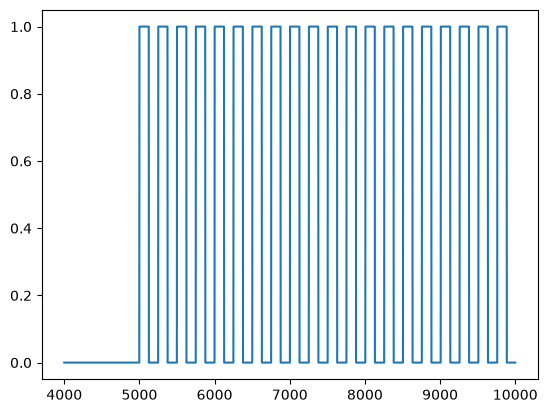

4000     0.0
4001     0.0
4002     0.0
4003     0.0
4004     0.0
        ... 
38439    0.0
38440    0.0
38441    0.0
38442    0.0
38443    0.0
Name: 13, Length: 34444, dtype: float64

In [4]:

plt.plot( data[13][4000:10000] )

plt.show()

stimulus = data[13][4000:]

stimulus

Seuil utilisé : 0.5
Nombre de pulses TTL détectés : 120


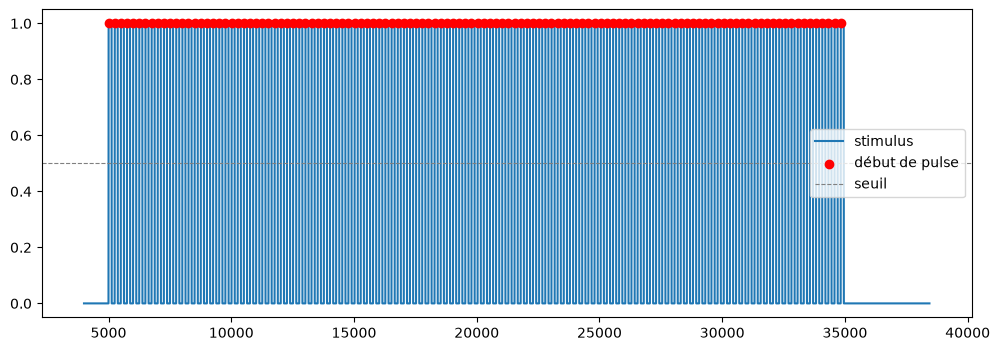

Index([ 4999,  5250,  5499,  5750,  6000,  6251,  6502,  6753,  7003,  7254,
       ...
       32571, 32822, 33072, 33323, 33574, 33824, 34075, 34326, 34576, 34827],
      dtype='int64', length=120)

In [5]:
threshold = (stimulus.max() + stimulus.min()) / 2
above = stimulus > threshold

onset_mask = above & ~above.shift(1, fill_value=False)
onsets = stimulus.index[onset_mask]

print(f"Seuil utilisé : {threshold}")
print(f"Nombre de pulses TTL détectés : {len(onsets)}")

plt.figure(figsize=(12, 4))
plt.plot(stimulus.index, stimulus.values, label='stimulus')
plt.scatter(onsets, stimulus.loc[onsets], color='red', zorder=3, label='début de pulse')
plt.axhline(threshold, color='gray', linestyle='--', linewidth=0.8, label='seuil')
plt.legend()
plt.show()

onsets


In [28]:
from scipy.signal import butter, filtfilt, iirnotch

fs = 250
print(f"Fréquence d'échantillonnage estimée : {fs:.2f} Hz")

def bandpass_filter(sig, low=1.0, high=40.0, fs=fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

def notch_filter(sig, freq=50.0, fs=fs, q=30):
    nyq = fs / 2
    b, a = iirnotch(freq / nyq, q)
    return filtfilt(b, a, sig)



Fréquence d'échantillonnage estimée : 250.00 Hz


Nombre d'epochs valides : 120


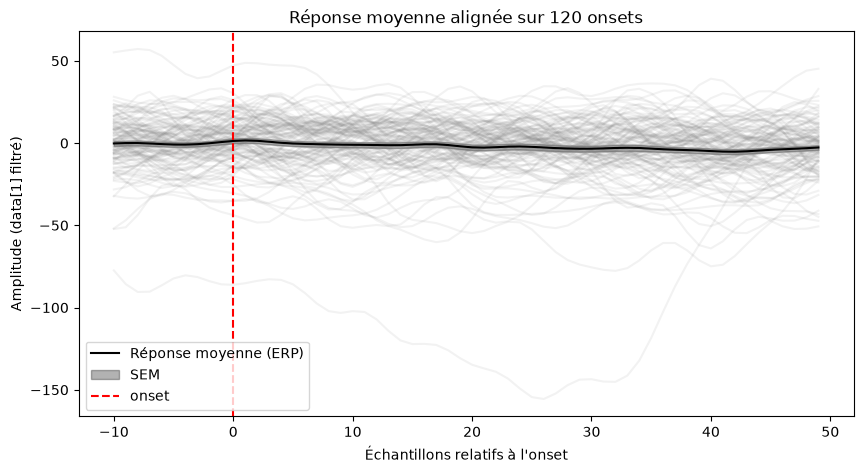

Nombre d'epochs valides : 120


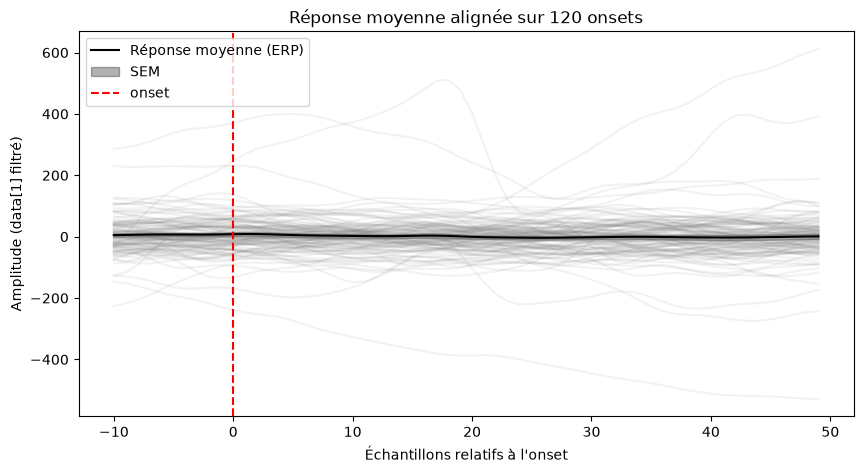

Nombre d'epochs valides : 120


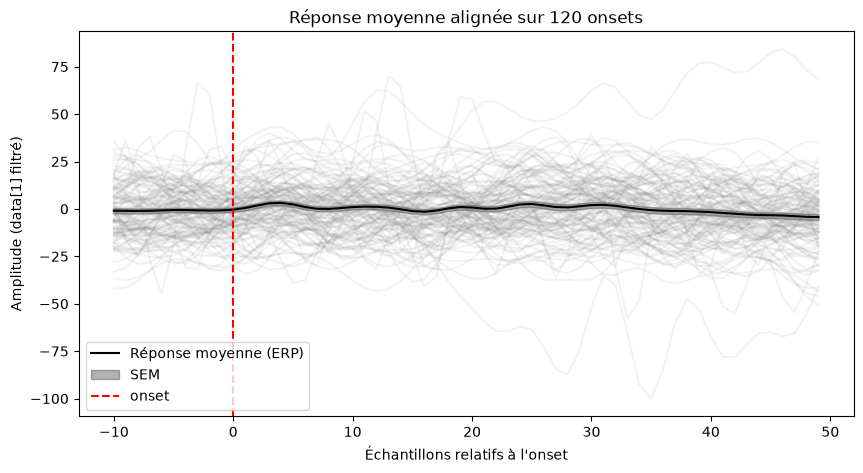

Nombre d'epochs valides : 120


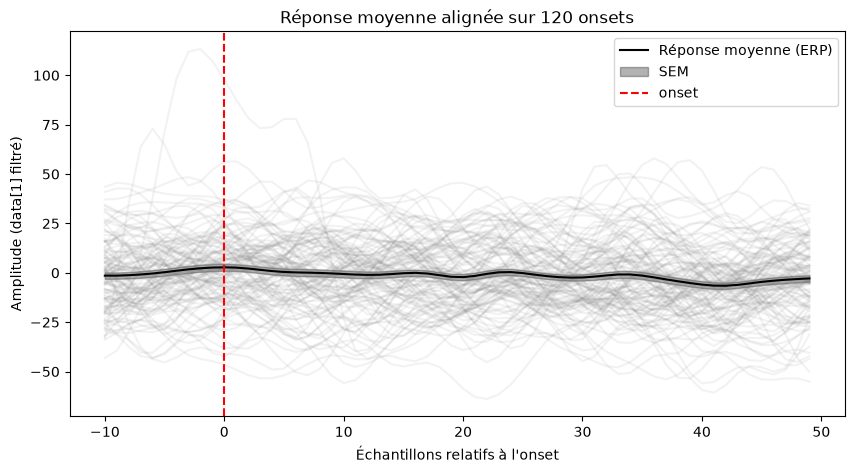

Nombre d'epochs valides : 120


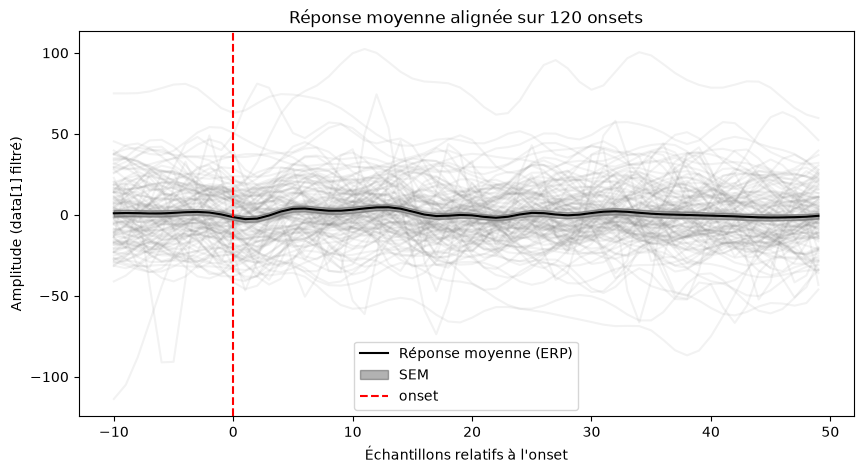

Nombre d'epochs valides : 120


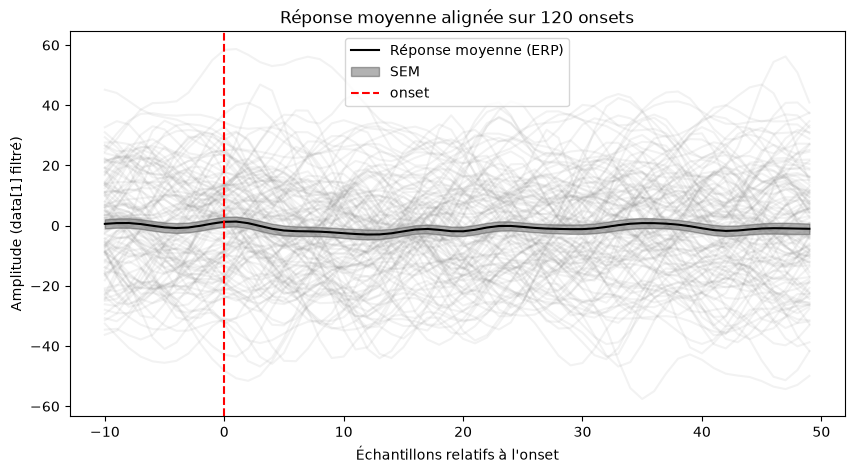

Nombre d'epochs valides : 120


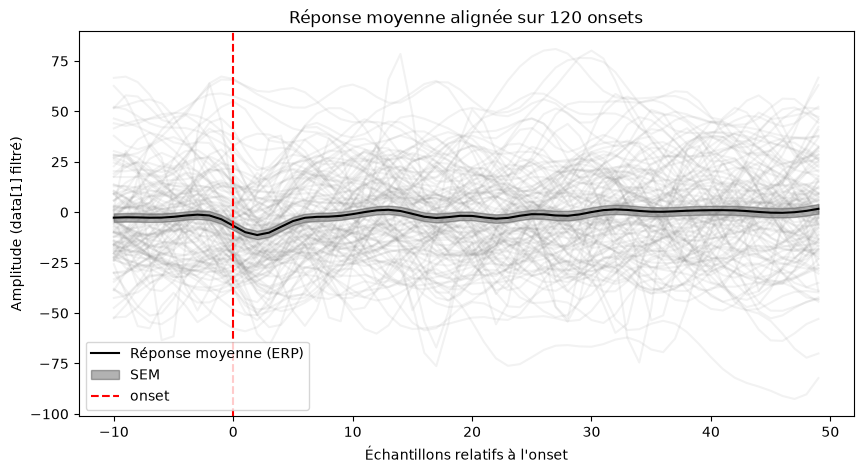

Nombre d'epochs valides : 120


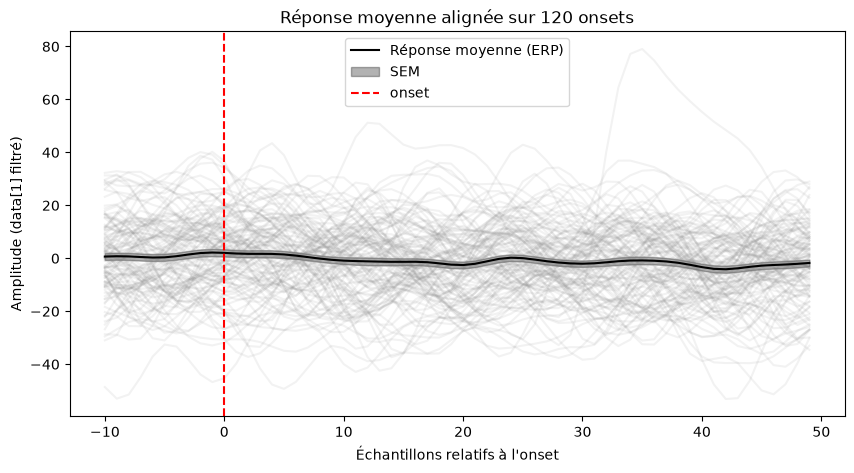

Nombre d'epochs valides : 120


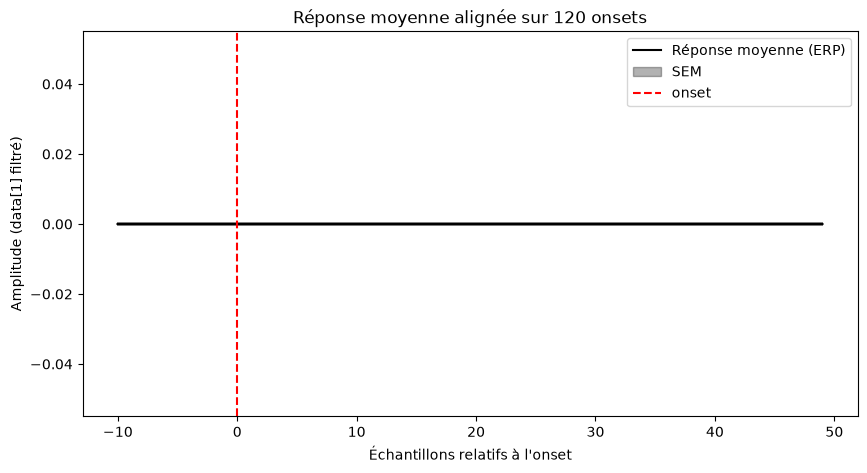

In [29]:
for channel in range(1,10):
        

    raw_signal = data[channel].to_numpy()
    eeg_filtered = notch_filter(bandpass_filter(raw_signal))

    # plt.figure(figsize=(12, 4))
    # plt.plot(raw_signal[4000:10000], alpha=0.5, label='brut')
    # plt.plot(eeg_filtered[4000:10000], label='filtré (passe-bande 1-40 Hz + notch 50 Hz)')
    # plt.legend()
    # plt.show()

    signal = eeg_filtered
    onsets_arr = np.asarray(onsets)

    pre = 10   # échantillons avant l'onset
    post = 50  # échantillons après l'onset

    valid = (onsets_arr - pre >= 0) & (onsets_arr + post < len(signal))
    onsets_valid = onsets_arr[valid]

    epochs = np.stack([signal[o - pre:o + post] for o in onsets_valid])
    time = np.arange(-pre, post)

    erp = epochs.mean(axis=0)
    sem = epochs.std(axis=0) / np.sqrt(epochs.shape[0])

    print(f"Nombre d'epochs valides : {epochs.shape[0]}")

    plt.figure(figsize=(10, 5))
    for e in epochs:
        plt.plot(time, e, color='gray', alpha=0.1)
    plt.plot(time, erp, color='black', label='Réponse moyenne (ERP)')
    plt.fill_between(time, erp - sem, erp + sem, color='black', alpha=0.3, label='SEM')
    plt.axvline(0, color='red', linestyle='--', label='onset')
    plt.xlabel("Échantillons relatifs à l'onset")
    plt.ylabel('Amplitude (data[1] filtré)')
    plt.title(f'Réponse moyenne alignée sur {epochs.shape[0]} onsets')
    plt.legend()
    plt.show()
